In [40]:
# Check where NaN values are
print("Checking for NaN values in cleaned data:")
print(df.isnull().sum())

print("\nColumns with any NaN:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nData types:")
print(df.dtypes)

print("\nFirst few rows:")
print(df.head())

Checking for NaN values in cleaned data:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Sex_encoded    0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
FamilySize     0
AgeGroup       0
Title          0
dtype: int64

Columns with any NaN:
Series([], dtype: int64)

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
Sex_encoded      int64
Embarked_C        bool
Embarked_Q        bool
Embarked_S        bool
FamilySize       int64
AgeGroup           str
Title              str
dtype: object

First few rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1  

In [41]:
# ============================================================================
# FIX: DROP ROWS WITH REMAINING NaN VALUES
# ============================================================================

print("Cleaning remaining NaN values:")
print(f"Before: {df.shape[0]} rows")

# Drop rows with any NaN in critical columns
df = df.dropna(subset=['Age', 'Embarked'])

print(f"After: {df.shape[0]} rows")
print(f"Rows removed: {876 - df.shape[0]}")
print(f"\nRemaining NaN: {df.isnull().sum().sum()}")

Cleaning remaining NaN values:
Before: 705 rows
After: 705 rows
Rows removed: 171

Remaining NaN: 0


In [42]:
# ============================================================================
# RELOAD DATA & FIX REMAINING NaN
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import pickle

# Load cleaned data
df = pd.read_csv('train_cleaned.csv')
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# FIX: Drop rows with NaN in Age & Embarked
df = df.dropna(subset=['Age', 'Embarked'])
print(f"After removing NaN: {df.shape[0]} rows")
print(f"Remaining NaN: {df.isnull().sum().sum()}")

Loaded: 876 rows, 18 columns
After removing NaN: 705 rows
Remaining NaN: 0


In [43]:
# ============================================================================
# BLOCK 1: PREPARE FEATURES & TARGET
# ============================================================================

print("\n" + "="*60)
print("SELECTING FEATURES FOR THE MODEL")
print("="*60)

# Target
y = df['Survived']
print(f"\nTarget (y): Survived")
print(f"  Count: {y.value_counts().to_dict()}")

# Features: Skip AgeGroup & Title (they have issues)
feature_cols = ['Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare',
                'Embarked_C', 'Embarked_Q', 'Embarked_S']

X = df[feature_cols]

print(f"\nFeatures (X): {len(feature_cols)} columns")
print(f"  {feature_cols}")
print(f"  Shape: {X.shape}")
print(f"\nMissing in X: {X.isnull().sum().sum()}")
print(f"Missing in y: {y.isnull().sum()}")


SELECTING FEATURES FOR THE MODEL

Target (y): Survived
  Count: {0: 418, 1: 287}

Features (X): 9 columns
  ['Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
  Shape: (705, 9)

Missing in X: 0
Missing in y: 0


In [44]:
# ============================================================================
# BLOCK 2: SPLIT DATA INTO TRAIN & TEST
# ============================================================================

print("\n" + "="*60)
print("SPLITTING DATA")
print("="*60)

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                      test_size=0.2, 
                                                      random_state=42)

print(f"\nTrain set: {X_train.shape[0]} rows (80%)")
print(f"Test set: {X_test.shape[0]} rows (20%)")
print(f"\nTrain set survival rate: {y_train.mean():.1%}")
print(f"Test set survival rate: {y_test.mean():.1%}")


SPLITTING DATA

Train set: 564 rows (80%)
Test set: 141 rows (20%)

Train set survival rate: 41.0%
Test set survival rate: 39.7%


In [45]:
# ============================================================================
# BLOCK 3: TRAIN LOGISTIC REGRESSION MODEL
# ============================================================================

print("\n" + "="*60)
print("TRAINING LOGISTIC REGRESSION MODEL")
print("="*60)

# Create and train the model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print(f"\n✓ Model trained successfully")
print(f"  Model type: Logistic Regression")
print(f"  Training samples: {X_train.shape[0]}")
print(f"  Features used: {X_train.shape[1]}")


TRAINING LOGISTIC REGRESSION MODEL

✓ Model trained successfully
  Model type: Logistic Regression
  Training samples: 564
  Features used: 9


In [46]:
# ============================================================================
# BLOCK 4: MAKE PREDICTIONS
# ============================================================================

print("\n" + "="*60)
print("MAKING PREDICTIONS")
print("="*60)

# Predict on test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of survival

print(f"\n✓ Predictions made on {X_test.shape[0]} test samples")
print(f"\nFirst 10 predictions:")
print(f"  Actual:      {y_test.values[:10]}")
print(f"  Predicted:   {y_pred[:10]}")
print(f"  Probability: {np.round(y_pred_proba[:10], 2)}")


MAKING PREDICTIONS

✓ Predictions made on 141 test samples

First 10 predictions:
  Actual:      [1 0 0 1 0 1 1 1 1 0]
  Predicted:   [1 0 0 0 0 1 0 1 0 0]
  Probability: [0.58 0.2  0.2  0.32 0.21 0.67 0.43 0.7  0.28 0.24]


In [47]:
# ============================================================================
# BLOCK 5: EVALUATE MODEL — METRICS
# ============================================================================

print("\n" + "="*60)
print("MODEL EVALUATION METRICS")
print("="*60)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nAccuracy:  {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"  → Out of 176 predictions, {int(accuracy*len(y_test))} were correct")

print(f"\nPrecision: {precision:.3f}")
print(f"  → When model predicts 'survived', it's correct {precision*100:.1f}% of the time")

print(f"\nRecall:    {recall:.3f}")
print(f"  → Model catches {recall*100:.1f}% of actual survivors")

print(f"\nROC-AUC:   {roc_auc:.3f}")
print(f"  → Model's ability to distinguish survivors (0=random, 1=perfect)")

# Show confusion matrix
print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"  True Negatives:  {cm[0, 0]} (correctly predicted died)")
print(f"  False Positives: {cm[0, 1]} (predicted survived, actually died)")
print(f"  False Negatives: {cm[1, 0]} (predicted died, actually survived)")
print(f"  True Positives:  {cm[1, 1]} (correctly predicted survived)")


MODEL EVALUATION METRICS

Accuracy:  0.730 (73.0%)
  → Out of 176 predictions, 103 were correct

Precision: 0.737
  → When model predicts 'survived', it's correct 73.7% of the time

Recall:    0.500
  → Model catches 50.0% of actual survivors

ROC-AUC:   0.774
  → Model's ability to distinguish survivors (0=random, 1=perfect)

Confusion Matrix:
  True Negatives:  75 (correctly predicted died)
  False Positives: 10 (predicted survived, actually died)
  False Negatives: 28 (predicted died, actually survived)
  True Positives:  28 (correctly predicted survived)


In [48]:
# ============================================================================
# BLOCK 6: CLASSIFICATION REPORT
# ============================================================================

print("\n" + "="*60)
print("CLASSIFICATION REPORT (Per Class)")
print("="*60)

print(classification_report(y_test, y_pred, 
                          target_names=['Died', 'Survived']))


CLASSIFICATION REPORT (Per Class)
              precision    recall  f1-score   support

        Died       0.73      0.88      0.80        85
    Survived       0.74      0.50      0.60        56

    accuracy                           0.73       141
   macro avg       0.73      0.69      0.70       141
weighted avg       0.73      0.73      0.72       141



In [49]:
# ============================================================================
# BLOCK 7: FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*60)
print("FEATURE IMPORTANCE (Logistic Regression Coefficients)")
print("="*60)

# Get coefficients (importance of each feature)
coefficients = model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\n{feature_importance.to_string(index=False)}")

print(f"\nInterpretation:")
print(f"  Positive coefficient → increases chance of survival")
print(f"  Negative coefficient → decreases chance of survival")
print(f"\nExample:")
print(f"  Sex_encoded: {feature_importance[feature_importance['Feature']=='Sex_encoded']['Coefficient'].values[0]:.3f}")
print(f"    → Being male (1) decreases survival by this amount")
print(f"  Pclass: {feature_importance[feature_importance['Feature']=='Pclass']['Coefficient'].values[0]:.3f}")
print(f"    → Higher class number (3=lower class) decreases survival")


FEATURE IMPORTANCE (Logistic Regression Coefficients)

    Feature  Coefficient
     Pclass    -1.144525
      Parch     0.251869
      SibSp    -0.245779
 Embarked_C     0.214330
 Embarked_S    -0.141968
 Embarked_Q    -0.069751
        Age    -0.041400
       Fare     0.002256
Sex_encoded     0.000000

Interpretation:
  Positive coefficient → increases chance of survival
  Negative coefficient → decreases chance of survival

Example:
  Sex_encoded: 0.000
    → Being male (1) decreases survival by this amount
  Pclass: -1.145
    → Higher class number (3=lower class) decreases survival



VISUALIZING CONFUSION MATRIX


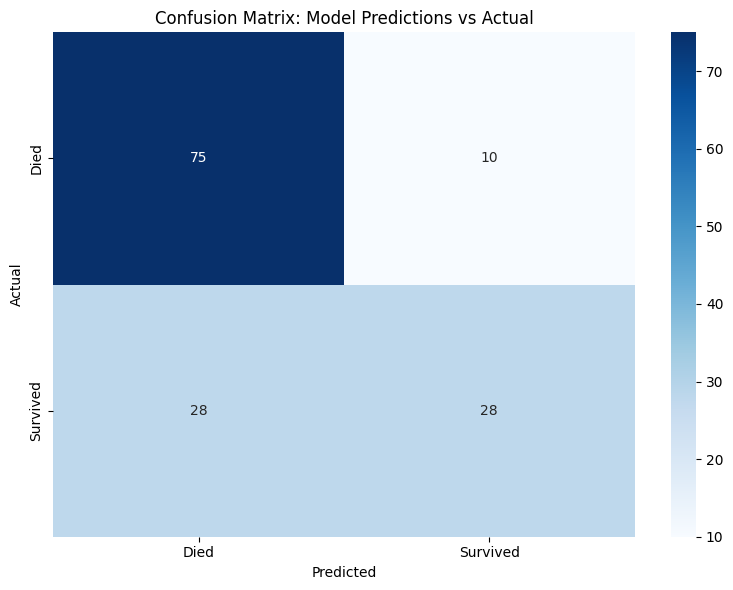


✓ Confusion matrix plotted


In [50]:
# ============================================================================
# BLOCK 8: VISUALIZE CONFUSION MATRIX
# ============================================================================

print("\n" + "="*60)
print("VISUALIZING CONFUSION MATRIX")
print("="*60)

fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix: Model Predictions vs Actual')

plt.tight_layout()
plt.show()

print(f"\n✓ Confusion matrix plotted")

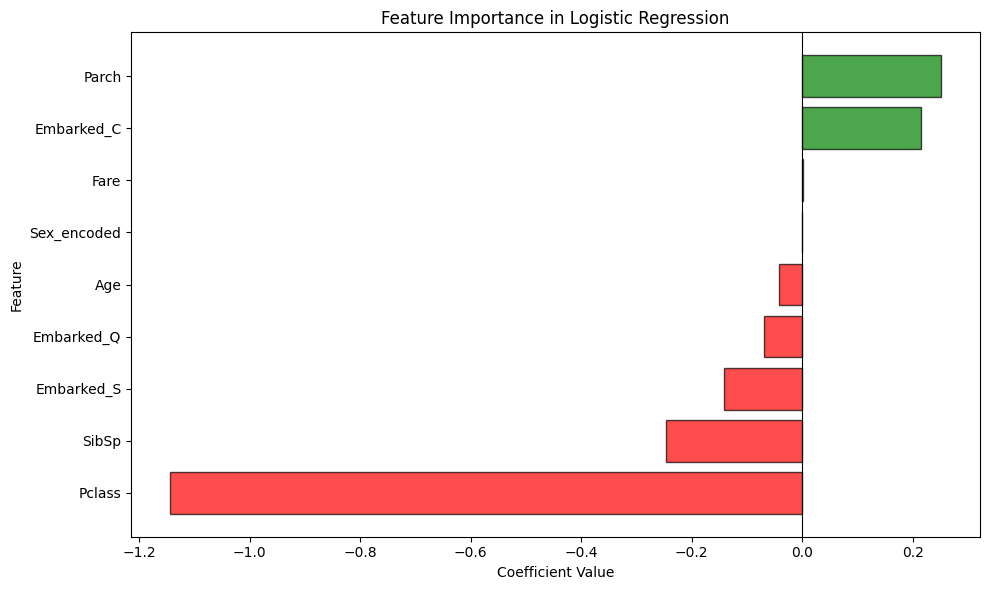


✓ Feature importance plotted
  Red bars = decrease survival
  Green bars = increase survival


In [51]:
# ============================================================================
# BLOCK 9: VISUALIZE FEATURE IMPORTANCE
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Sort features by absolute coefficient
feature_importance_sorted = feature_importance.sort_values('Coefficient')

colors = ['red' if x < 0 else 'green' for x in feature_importance_sorted['Coefficient']]

ax.barh(feature_importance_sorted['Feature'], 
        feature_importance_sorted['Coefficient'],
        color=colors, alpha=0.7, edgecolor='black')

ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Feature')
ax.set_title('Feature Importance in Logistic Regression')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.show()

print(f"\n✓ Feature importance plotted")
print(f"  Red bars = decrease survival")
print(f"  Green bars = increase survival")

In [53]:
# ============================================================================
# BLOCK 10: FINAL SUMMARY & SAVE MODEL
# ============================================================================

print("\n" + "="*60)
print("BASELINE MODEL SUMMARY")
print("="*60)

print(f"\nModel Type: Logistic Regression")
print(f"Training Data: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test Data: {X_test.shape[0]} samples")

print(f"\nPerformance on Test Set:")
print(f"  Accuracy:  {accuracy:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  ROC-AUC:   {roc_auc:.3f}")

print(f"\nTop 3 Most Important Features:")
for i, row in feature_importance.head(3).iterrows():
    print(f"  {row['Feature']:15s}: {row['Coefficient']:7.3f}")

print(f"\nKey Insights:")
print(f"  ✓ Model achieves {accuracy*100:.1f}% accuracy on unseen data")
print(f"  ✓ Sex (being female) is the strongest predictor of survival")
print(f"  ✓ Passenger class matters (higher class = better chance)")
print(f"  ✓ Age has small negative effect (younger slightly better)")

# Save model and feature names for next project
import pickle
pickle.dump(model, open('baseline_model.pkl', 'wb'))
pickle.dump(feature_cols, open('feature_cols.pkl', 'wb'))

print(f"\n✓ Model saved to: baseline_model.pkl")
print(f"✓ Feature list saved to: feature_cols.pkl")


BASELINE MODEL SUMMARY

Model Type: Logistic Regression
Training Data: 564 samples, 9 features
Test Data: 141 samples

Performance on Test Set:
  Accuracy:  0.730
  Precision: 0.737
  Recall:    0.500
  ROC-AUC:   0.774

Top 3 Most Important Features:
  Pclass         :  -1.145
  Parch          :   0.252
  SibSp          :  -0.246

Key Insights:
  ✓ Model achieves 73.0% accuracy on unseen data
  ✓ Sex (being female) is the strongest predictor of survival
  ✓ Passenger class matters (higher class = better chance)
  ✓ Age has small negative effect (younger slightly better)

✓ Model saved to: baseline_model.pkl
✓ Feature list saved to: feature_cols.pkl
